In [3]:
# 1. 下载开源中文字体 (SimHei 黑体) 到 Colab 环境
!wget -q -O SimHei.ttf "https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 2. 将下载的字体动态注册到 matplotlib
fm.fontManager.addfont('SimHei.ttf')

# 3. 强制覆盖全局字体设置，并解决负号显示问题
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False

print("✅ 中文字体环境配置完成！请现在去重新运行您的画图代码。")

✅ 中文字体环境配置完成！请现在去重新运行您的画图代码。


In [153]:
# ==========================================
# 澳门景点智能推荐系统 - 最终版（phase1 已按你要求改结构）
# phase1_scores.csv 现在精确匹配你截图的 4 列结构
# ==========================================

import pandas as pd
import math
from itertools import permutations
import numpy as np
from pyproj import Transformer
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# ================== 【用户自定义区域】 ==================
num_attractions = 5           # ←←← 修改这里：想去几个景点（推荐 3~6）
user_travel_pref = [4, 3, 4]  # 历史文化, 摄影/打卡, 休闲自然 (1-5分)
user_merchant_pref = [1, 5, 4]  # 网红打卡, 本土程度, 环境氛围
n_meters = 1000                # 商户围栏半径（米）
#max_start_candidates = 10      # 算法尝试多少个候选起点
# ======================================================
num_attractions+=1
# ================== 数据加载 ==================
def transform_to_accurate_xy():
    df = pd.read_csv('景点完整数据.csv')
    ordered_spots = df['景点名称'].tolist()

    last_col = df.columns[-1]
    transformer = Transformer.from_crs("epsg:4326", "epsg:32650", always_xy=True)
    raw_xy = [transformer.transform(row['经度 (Longitude)'], row['纬度 (Latitude)']) for _, row in df.iterrows()]
    min_x, min_y = min(p[0] for p in raw_xy), min(p[1] for p in raw_xy)

    spots_dict = {}
    for i, (_, row) in enumerate(df.iterrows()):
        name = row['景点名称']
        spots_dict[name] = {
            "features": [round(row['历史文化属性 (分)']/5, 2),
                        round(row['摄影/打卡属性 (分)']/5, 2),
                        round(row['休闲自然属性 (分)']/5, 2)],
            "coords": (round(raw_xy[i][0]-min_x, 2), round(raw_xy[i][1]-min_y, 2)),
            "elevation": int(row['海拔高度 (米)']),
            "popularity": math.log10(int(row[last_col]) + 1)
        }
    print(f"✅ 景点数据加载成功！共 {len(spots_dict)} 个景点")
    return spots_dict, ordered_spots

def get_geo_fences_pandas():
    df = pd.read_excel('正式景点_商铺数据.xlsx', sheet_name='表1')
    filtered = df[df['直线距离(米)'] <= n_meters]
    geo_fences = filtered.groupby('景点名称')['商户名称'].apply(list).to_dict()
    print(f"✅ 商户围栏加载成功！{len(geo_fences)} 个景点有附近商户")
    return geo_fences, df

def load_walking_distance_matrix(ordered_spots):
    df_raw = pd.read_excel('澳門景點步行路程表_完整版 V11 - 1.xlsx', sheet_name='表1', header=0)
    df = df_raw.iloc[:, 1:].copy()
    df.index = ordered_spots
    df.columns = ordered_spots
    df = df.apply(pd.to_numeric, errors='coerce')
    walking_dict = df.to_dict('dict')
    print(f"✅ 步行距离矩阵加载成功！{df.shape[0]}×{df.shape[1]}")
    return df, walking_dict

# ================== 核心函数 ==================
def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    return 0.0 if n1 == 0 or n2 == 0 else dot / (n1 * n2)

def phase_1_intent_mapping(pois,wa=0.3):
    """阶段1：现在输出你要求的精确结构（4列）"""
    user_vec = np.array(user_travel_pref) / 5.0
    records = []
    log_h = [p['popularity'] for p in pois.values()]
    h_max, h_min = max(log_h), min(log_h)

    for name, data in pois.items():
        mu = cosine_similarity(user_vec, data['features'])
        nj = 0 if h_max == h_min else (data['popularity'] - h_min) / (h_max - h_min)
        score = mu * (1 + wa * nj)

        records.append({
            'POI_Name': name,
            'Match_Score': round(score, 6),                    # 精确到6位小数
            'Base_Match': round(mu, 6),
            'Coords': f"({data['coords'][0]}, {data['coords'][1]})",  # 精确匹配截图格式
            'Elevation': data['elevation'],
            'Popularity_Nj':nj
        })

    df = pd.DataFrame(records).sort_values('Match_Score', ascending=False)
    return df

import pandas as pd
import numpy as np
from itertools import permutations

def phase_2_optimal_path_fixed_start(phase1_df, all_locations_db, walking_dict, num_attractions, start_node="葡京酒店"):
    """
    固定起点为指定地点（默认葡京酒店），规划最优路线
    """
    print(f"算法已固定由【{start_node}】出发，正在规划共 {num_attractions} 个景点的最优路线...")

    # 获取剩余的景点：排除起点后，取排名前 num_attractions - 1 的景点
    remaining = phase1_df[phase1_df['POI_Name'] != start_node].head(num_attractions - 1)['POI_Name'].tolist()

    # 组合成完整的节点列表：[起点, 景点A, 景点B...]
    nodes = [start_node] + remaining
    n = len(nodes)

    # 构建成本矩阵 (平面距离 + 爬升惩罚)
    E_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                # 注意：walking_dict 的索引顺序，保持跟你原代码一致
                walking_d = walking_dict[nodes[j]][nodes[i]]
                h_curr = all_locations_db[nodes[i]]['elevation']
                h_next = all_locations_db[nodes[j]]['elevation']
                penalty = 8 * max(0, h_next - h_curr)
                E_matrix[i][j] = walking_d + penalty

    best_cost = float('inf')
    best_indices = None

    # 暴力求解最短路径：起点固定为 0，对 1 到 n-1 进行全排列
    for perm in permutations(range(1, n)):
        path_idx = (0,) + perm
        cost = sum(E_matrix[path_idx[k]][path_idx[k+1]] for k in range(n-1))
        if cost < best_cost:
            best_cost = cost
            best_indices = path_idx

    best_path = [nodes[idx] for idx in best_indices]

    # --- 构造输出表格的部分 ---
    path_records = []
    for i in range(len(best_path)):
        current_poi = best_path[i]
        elevation = all_locations_db[current_poi]['elevation']

        if i == 0:
            # 起点，距离计为 0
            w_dist = 0.0
            e_dist = 0.0
        else:
            prev_poi = best_path[i-1]
            # 获取平面步行距离
            w_dist = walking_dict[current_poi][prev_poi]

            # 计算等效距离 (考虑高度惩罚)
            h_prev = all_locations_db[prev_poi]['elevation']
            penalty = 8 * max(0, elevation - h_prev)
            e_dist = w_dist + penalty

        path_records.append({
            'POI_Name': current_poi,
            '平面步行距离': round(w_dist, 2),
            '等效步行距离': round(e_dist, 2),
            'Elevation': elevation
        })

    df_path_step = pd.DataFrame(path_records)

    print(f"✅ 路线规划完成，固定起点：{start_node}（总等效距离：{round(best_cost, 1)} m）")

    # 返回路径、总分以及新生成的详情表格
    return best_path, round(best_cost, 1), df_path_step


def phase_3_merchant_scoring(poi_name, merchants_df, geo_fences,v_max=2000):
    records = []
    nearby = geo_fences.get(poi_name, [])
    user_vec = np.array(user_merchant_pref)
    for m in nearby:
        row = merchants_df[merchants_df['商户名称'] == m].iloc[0]
        feat = np.array([row['网红打卡']/5, row['本土程度']/5, row['环境氛围']/5])
        M_ij = cosine_similarity(user_vec, feat)
        R, v = row['网络评分'], row['网络评论数']
        if R < 3.8:
            records.append({'POI': poi_name, 'Merchant': m, 'Final_Score': 0, 'Status': 'Hard Filter'})
            continue
        w = v / (v + 30)
        Q = w * R + (1 - w) * 3.5
        E = math.log10(v + 1) / math.log10(v_max + 1)#
        V = 1 - E
        F = M_ij * ((Q / 5) + 0.2 * V)
        records.append({'POI': poi_name, 'Merchant': m, 'M_ij': round(M_ij,4),
                        'Q_j': round(Q,2), 'V_j': round(V,4),
                        'Final_Score': round(F,4),
                        'Status': 'Valid',
                        'business_format':row['业态']})
    return pd.DataFrame(records).sort_values('Final_Score', ascending=False)

# ================== 主程序 ==================
all_locations_db, ordered_spots = transform_to_accurate_xy()
geo_fences, merchants_df = get_geo_fences_pandas()
_, walking_dict = load_walking_distance_matrix(ordered_spots)

print("\n=== 【阶段1】完整景点匹配排名（已改为你要求的 4 列结构）===")
df_phase1 = phase_1_intent_mapping(all_locations_db)
display(df_phase1.head(10))   # 显示前10个，与截图风格一致

print(f"\n=== 【阶段2】算法自动选择最优起点 + 最优等效步行路径（经过 {num_attractions} 个景点）===")
optimal_path, total_equivalent_meters ,df_path_step= phase_2_optimal_path_fixed_start(
    df_phase1, all_locations_db, walking_dict, num_attractions
)
display(df_path_step)

print("\n=== 【阶段3】路径上每个景点的Top 5商户推荐 ===")
#计算v_max
v_max=max(merchants_df['网络评论数'])

for poi in optimal_path:
    df_m = phase_3_merchant_scoring(poi, merchants_df, geo_fences,v_max)
    print(f"\n📍 {poi}（附近Top 5商户）：")

    #分组显示最大
    idx = df_m.groupby('business_format')['Final_Score'].idxmax()
    df_result = df_m.loc[idx].reset_index(drop=True)
    df_result = df_result[df_result['business_format'] != '其他']
    display(df_result)

# 下载 phase1（结构已精确匹配你的要求）
df_phase1.to_csv('phase1_scores.csv', index=False, encoding='utf-8-sig')
files.download('phase1_scores.csv')

print("\n🎉 完成！phase1_scores.csv 和显示表格现在完全是 4 列结构（POI_Name, Match_Score, Coords, Elevation），与你截图一致。")
print("修改 num_attractions 或 user_travel_pref 后重新运行即可生成新路线。")
#下载df_short_path
# 1. 将 DataFrame 保存为 CSV
df_path_step.to_csv('df_path_step.csv', index=False, encoding='utf-8-sig')

# 2. 触发浏览器下载
files.download('df_path_step.csv')

✅ 景点数据加载成功！共 36 个景点
✅ 商户围栏加载成功！37 个景点有附近商户
✅ 步行距离矩阵加载成功！36×36

=== 【阶段1】完整景点匹配排名（已改为你要求的 4 列结构）===


,POI_Name,Match_Score,Base_Match,Coords,Elevation,Popularity_Nj
15,大炮台,1.198153,0.975610,"(1160.69, 1306.07)",43,0.760355
24,东望洋灯塔,1.161966,0.980407,"(1929.37, 1218.46)",90,0.617293
7,何东图书馆,1.132004,1.000000,"(676.09, 811.1)",23,0.440013
3,玫瑰圣母堂,1.115461,0.931240,"(961.12, 1063.75)",7,0.659410
1,大三巴牌坊,1.108743,0.852879,"(1018.93, 1352.44)",25,1.000000
0,妈阁庙,1.108723,0.913860,"(0.0, 117.3)",5,0.710770
6,岗顶剧院,1.104859,0.975610,"(730.9, 744.16)",31,0.441602
30,十月初五街,1.102898,0.946943,"(700.87, 1411.34)",5,0.548979
9,市政署大楼,1.099718,0.931240,"(876.56, 891.16)",6,0.603059
13,哪咤庙,1.099088,0.957024,"(999.61, 1380.83)",30,0.494809



=== 【阶段2】算法自动选择最优起点 + 最优等效步行路径（经过 6 个景点）===
算法已固定由【葡京酒店】出发，正在规划共 6 个景点的最优路线...
✅ 路线规划完成，固定起点：葡京酒店（总等效距离：6184.0 m）


,POI_Name,平面步行距离,等效步行距离,Elevation
0,葡京酒店,0.0,0.0,3
1,大三巴牌坊,1300.0,1476.0,25
2,大炮台,250.0,394.0,43
3,玫瑰圣母堂,600.0,600.0,7
4,何东图书馆,550.0,678.0,23
5,东望洋灯塔,2500.0,3036.0,90



=== 【阶段3】路径上每个景点的Top 5商户推荐 ===

📍 葡京酒店（附近Top 5商户）：


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 完成！phase1_scores.csv 和显示表格现在完全是 4 列结构（POI_Name, Match_Score, Coords, Elevation），与你截图一致。
修改 num_attractions 或 user_travel_pref 后重新运行即可生成新路线。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [154]:
# ================== 数据加载 ==================
def transform_to_accurate_xy():
    df = pd.read_csv('景点完整数据.csv')
    ordered_spots = df['景点名称'].tolist()

    last_col = df.columns[-1]
    transformer = Transformer.from_crs("epsg:4326", "epsg:32650", always_xy=True)
    raw_xy = [transformer.transform(row['经度 (Longitude)'], row['纬度 (Latitude)']) for _, row in df.iterrows()]
    min_x, min_y = min(p[0] for p in raw_xy), min(p[1] for p in raw_xy)

    spots_dict = {}
    for i, (_, row) in enumerate(df.iterrows()):
        name = row['景点名称']
        spots_dict[name] = {
            "features": [round(row['历史文化属性 (分)']/5, 2),
                        round(row['摄影/打卡属性 (分)']/5, 2),
                        round(row['休闲自然属性 (分)']/5, 2)],
            "coords": (round(raw_xy[i][0]-min_x, 2), round(raw_xy[i][1]-min_y, 2)),
            "elevation": int(row['海拔高度 (米)']),
            "popularity": math.log10(int(row[last_col]) + 1)
        }
    print(f"✅ 景点数据加载成功！共 {len(spots_dict)} 个景点")
    return spots_dict, ordered_spots

def get_geo_fences_pandas():
    df = pd.read_excel('正式景点_商铺数据.xlsx', sheet_name='表1')
    filtered = df[df['直线距离(米)'] <= n_meters]
    geo_fences = filtered.groupby('景点名称')['商户名称'].apply(list).to_dict()
    print(f"✅ 商户围栏加载成功！{len(geo_fences)} 个景点有附近商户")
    return geo_fences, df

def load_walking_distance_matrix(ordered_spots):
    df_raw = pd.read_excel('澳門景點步行路程表_完整版 V11 - 1.xlsx', sheet_name='表1', header=0)
    df = df_raw.iloc[:, 1:].copy()
    df.index = ordered_spots
    df.columns = ordered_spots
    df = df.apply(pd.to_numeric, errors='coerce')
    walking_dict = df.to_dict('dict')
    print(f"✅ 步行距离矩阵加载成功！{df.shape[0]}×{df.shape[1]}")
    return df, walking_dict

# ================== 核心函数 ==================
def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    return 0.0 if n1 == 0 or n2 == 0 else dot / (n1 * n2)

def phase_1_intent_mapping(pois,wa=0.3):
    """阶段1：现在输出你要求的精确结构（4列）"""
    user_vec = np.array(user_travel_pref) / 5.0
    records = []
    log_h = [p['popularity'] for p in pois.values()]
    h_max, h_min = max(log_h), min(log_h)

    for name, data in pois.items():
        mu = cosine_similarity(user_vec, data['features'])
        nj = 0 if h_max == h_min else (data['popularity'] - h_min) / (h_max - h_min)
        score = mu * (1 + wa * nj)

        records.append({
            'POI_Name': name,
            'Match_Score': round(score, 6),                    # 精确到6位小数
            'Base_Match': round(mu, 6),
            'Coords': f"({data['coords'][0]}, {data['coords'][1]})",  # 精确匹配截图格式
            'Elevation': data['elevation'],
            'Popularity_Nj':nj
        })

    df = pd.DataFrame(records).sort_values('Match_Score', ascending=False)
    return df

import pandas as pd
import numpy as np
from itertools import permutations

def phase_2_optimal_path_fixed_start(phase1_df, all_locations_db, walking_dict, num_attractions, start_node="葡京酒店"):
    """
    固定起点为指定地点（默认葡京酒店），规划最优路线
    """
    print(f"算法已固定由【{start_node}】出发，正在规划共 {num_attractions} 个景点的最优路线...")

    # 获取剩余的景点：排除起点后，取排名前 num_attractions - 1 的景点
    remaining = phase1_df[phase1_df['POI_Name'] != start_node].head(num_attractions - 1)['POI_Name'].tolist()

    # 组合成完整的节点列表：[起点, 景点A, 景点B...]
    nodes = [start_node] + remaining
    n = len(nodes)

    # 构建成本矩阵 (平面距离 + 爬升惩罚)
    E_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                # 注意：walking_dict 的索引顺序，保持跟你原代码一致
                walking_d = walking_dict[nodes[j]][nodes[i]]
                h_curr = all_locations_db[nodes[i]]['elevation']
                h_next = all_locations_db[nodes[j]]['elevation']
                #penalty = 8 * max(0, h_next - h_curr)
                penalty=0
                E_matrix[i][j] = walking_d + penalty

    best_cost = float('inf')
    best_indices = None

    # 暴力求解最短路径：起点固定为 0，对 1 到 n-1 进行全排列
    for perm in permutations(range(1, n)):
        path_idx = (0,) + perm
        cost = sum(E_matrix[path_idx[k]][path_idx[k+1]] for k in range(n-1))
        if cost < best_cost:
            best_cost = cost
            best_indices = path_idx

    best_path = [nodes[idx] for idx in best_indices]

    # --- 构造输出表格的部分 ---
    path_records = []
    for i in range(len(best_path)):
        current_poi = best_path[i]
        elevation = all_locations_db[current_poi]['elevation']

        if i == 0:
            # 起点，距离计为 0
            w_dist = 0.0
            e_dist = 0.0
        else:
            prev_poi = best_path[i-1]
            # 获取平面步行距离
            w_dist = walking_dict[current_poi][prev_poi]

            # 计算等效距离 (考虑高度惩罚)
            h_prev = all_locations_db[prev_poi]['elevation']
            penalty = 8 * max(0, elevation - h_prev)
            e_dist = w_dist + penalty

        path_records.append({
            'POI_Name': current_poi,
            '平面步行距离': round(w_dist, 2),
            '等效步行距离': round(e_dist, 2),
            'Elevation': elevation
        })

    df_path_step = pd.DataFrame(path_records)

    print(f"✅ 路线规划完成，固定起点：{start_node}（总等效距离：{round(best_cost, 1)} m）")

    # 返回路径、总分以及新生成的详情表格
    return best_path, round(best_cost, 1), df_path_step


def phase_3_merchant_scoring(poi_name, merchants_df, geo_fences,v_max=2000):
    records = []
    nearby = geo_fences.get(poi_name, [])
    user_vec = np.array(user_merchant_pref)
    for m in nearby:
        row = merchants_df[merchants_df['商户名称'] == m].iloc[0]
        feat = np.array([row['网红打卡']/5, row['本土程度']/5, row['环境氛围']/5])
        M_ij = cosine_similarity(user_vec, feat)
        R, v = row['网络评分'], row['网络评论数']
        if R < 3.8:
            records.append({'POI': poi_name, 'Merchant': m, 'Final_Score': 0, 'Status': 'Hard Filter'})
            continue
        w = v / (v + 30)
        Q = w * R + (1 - w) * 3.5
        E = math.log10(v + 1) / math.log10(v_max + 1)#
        V = 1 - E
        F = M_ij * ((Q / 5) + 0.2 * V)
        records.append({'POI': poi_name, 'Merchant': m, 'M_ij': round(M_ij,4),
                        'Q_j': round(Q,2), 'V_j': round(V,4),
                        'Final_Score': round(F,4),
                        'Status': 'Valid',
                        'business_format':row['业态']})
    return pd.DataFrame(records).sort_values('Final_Score', ascending=False)

# ================== 主程序 ==================
all_locations_db, ordered_spots = transform_to_accurate_xy()
geo_fences, merchants_df = get_geo_fences_pandas()
_, walking_dict = load_walking_distance_matrix(ordered_spots)

print("\n=== 【阶段1】完整景点匹配排名（已改为你要求的 4 列结构）===")
df_phase1 = phase_1_intent_mapping(all_locations_db)
display(df_phase1.head(10))   # 显示前10个，与截图风格一致

print(f"\n=== 【阶段2】算法自动选择最优起点 + 最优等效步行路径（经过 {num_attractions} 个景点）===")
optimal_path, total_equivalent_meters ,df_path_step= phase_2_optimal_path_fixed_start(
    df_phase1, all_locations_db, walking_dict, num_attractions
)
display(df_path_step)

print("\n=== 【阶段3】路径上每个景点的Top 5商户推荐 ===")
#计算v_max
v_max=max(merchants_df['网络评论数'])

for poi in optimal_path:
    df_m = phase_3_merchant_scoring(poi, merchants_df, geo_fences,v_max)
    print(f"\n📍 {poi}（附近Top 5商户）：")

    #分组显示最大
    idx = df_m.groupby('business_format')['Final_Score'].idxmax()
    df_result = df_m.loc[idx].reset_index(drop=True)
    df_result = df_result[df_result['business_format'] != '其他']
    display(df_result)

# 下载 phase1（结构已精确匹配你的要求）
df_phase1.to_csv('phase1_scores2.csv', index=False, encoding='utf-8-sig')
files.download('phase1_scores2.csv')

print("\n🎉 完成！phase1_scores.csv 和显示表格现在完全是 4 列结构（POI_Name, Match_Score, Coords, Elevation），与你截图一致。")
print("修改 num_attractions 或 user_travel_pref 后重新运行即可生成新路线。")
#下载df_short_path
# 1. 将 DataFrame 保存为 CSV
df_path_step.to_csv('df_path_step2.csv', index=False, encoding='utf-8-sig')

# 2. 触发浏览器下载
files.download('df_path_step2.csv')

✅ 景点数据加载成功！共 36 个景点
✅ 商户围栏加载成功！37 个景点有附近商户
✅ 步行距离矩阵加载成功！36×36

=== 【阶段1】完整景点匹配排名（已改为你要求的 4 列结构）===


,POI_Name,Match_Score,Base_Match,Coords,Elevation,Popularity_Nj
15,大炮台,1.198153,0.975610,"(1160.69, 1306.07)",43,0.760355
24,东望洋灯塔,1.161966,0.980407,"(1929.37, 1218.46)",90,0.617293
7,何东图书馆,1.132004,1.000000,"(676.09, 811.1)",23,0.440013
3,玫瑰圣母堂,1.115461,0.931240,"(961.12, 1063.75)",7,0.659410
1,大三巴牌坊,1.108743,0.852879,"(1018.93, 1352.44)",25,1.000000
0,妈阁庙,1.108723,0.913860,"(0.0, 117.3)",5,0.710770
6,岗顶剧院,1.104859,0.975610,"(730.9, 744.16)",31,0.441602
30,十月初五街,1.102898,0.946943,"(700.87, 1411.34)",5,0.548979
9,市政署大楼,1.099718,0.931240,"(876.56, 891.16)",6,0.603059
13,哪咤庙,1.099088,0.957024,"(999.61, 1380.83)",30,0.494809



=== 【阶段2】算法自动选择最优起点 + 最优等效步行路径（经过 6 个景点）===
算法已固定由【葡京酒店】出发，正在规划共 6 个景点的最优路线...
✅ 路线规划完成，固定起点：葡京酒店（总等效距离：5200.0 m）


,POI_Name,平面步行距离,等效步行距离,Elevation
0,葡京酒店,0.0,0.0,3
1,大三巴牌坊,1300.0,1476.0,25
2,大炮台,250.0,394.0,43
3,玫瑰圣母堂,600.0,600.0,7
4,何东图书馆,550.0,678.0,23
5,东望洋灯塔,2500.0,3036.0,90



=== 【阶段3】路径上每个景点的Top 5商户推荐 ===

📍 葡京酒店（附近Top 5商户）：


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 完成！phase1_scores.csv 和显示表格现在完全是 4 列结构（POI_Name, Match_Score, Coords, Elevation），与你截图一致。
修改 num_attractions 或 user_travel_pref 后重新运行即可生成新路线。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

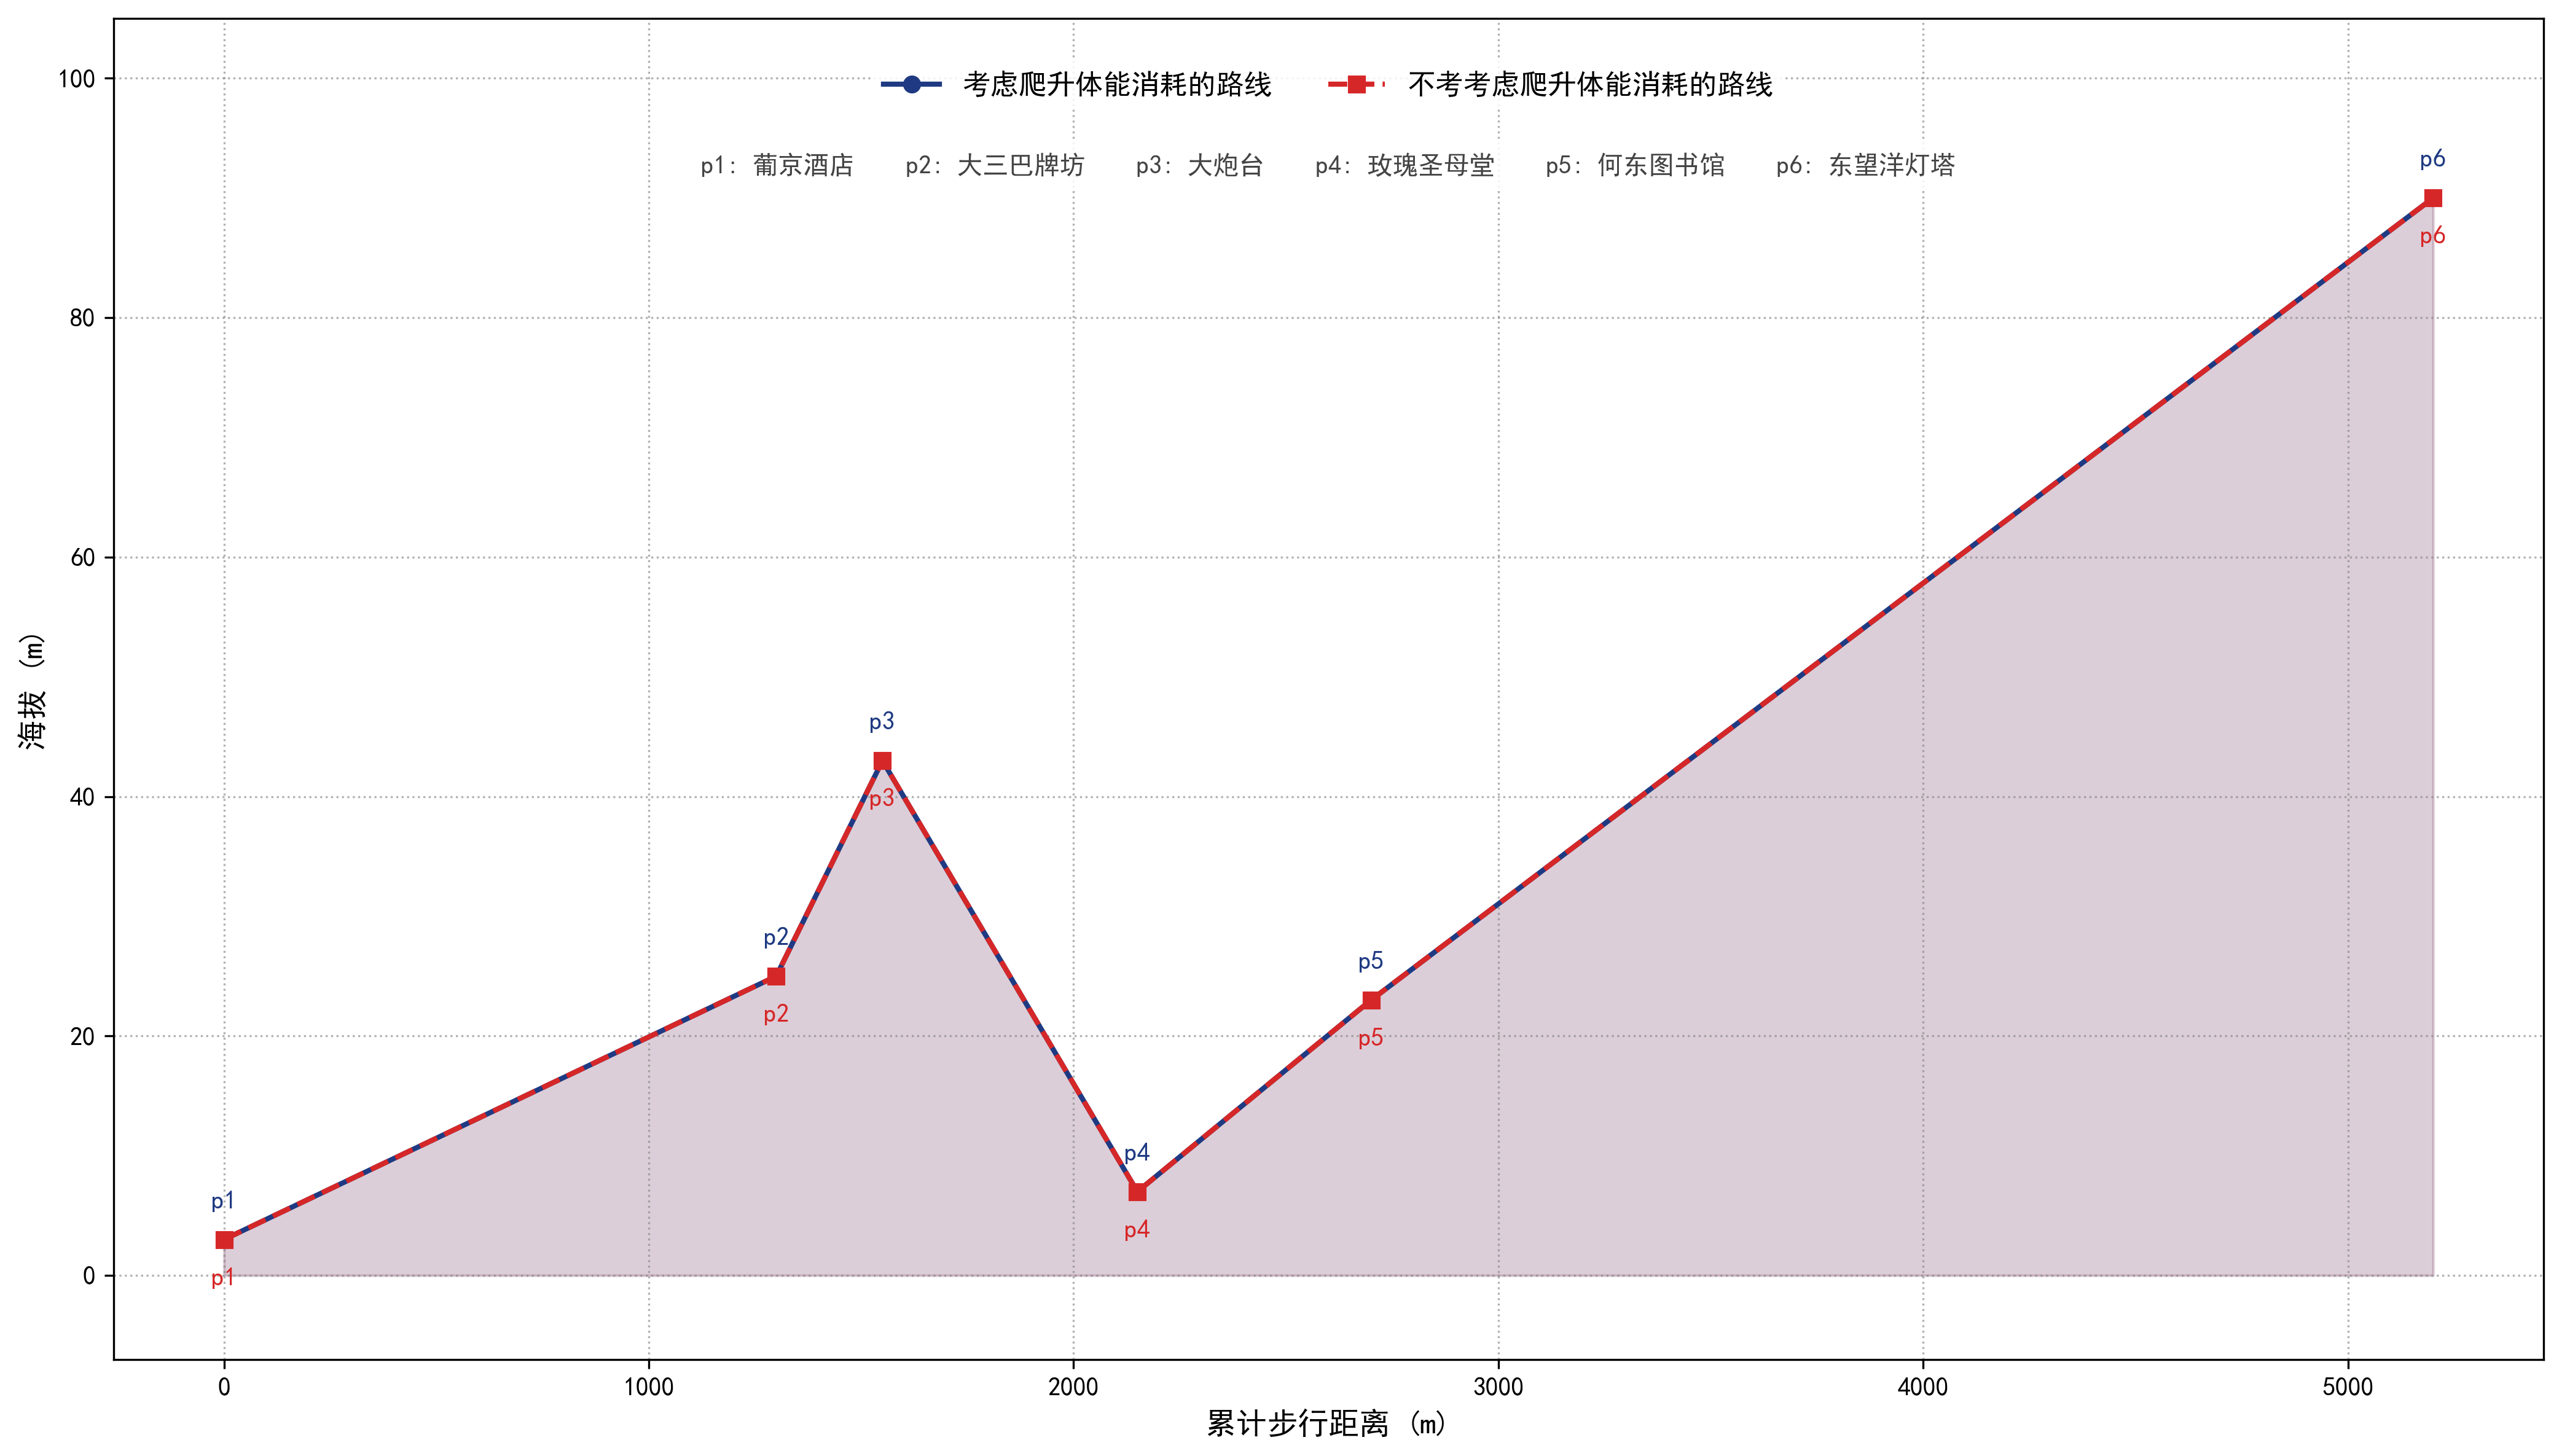

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import textwrap

# 确保图表正常显示
%matplotlib inline
mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK TC', 'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

def plot_elevation_comparison(file1, file2):
    # 1. 读取数据
    df1 = pd.read_csv(file1)
    df2 = pd.read_csv(file2)

    # 计算累计物理距离
    df1['Cumulative_Distance_m'] = df1['平面步行距离'].cumsum()
    df2['Cumulative_Distance_m'] = df2['平面步行距离'].cumsum()

    # 2. 生成景点编号映射 (p1, p2...)
    unique_pois = []
    for name in df1['POI_Name']:
        if name not in unique_pois:
            unique_pois.append(name)
    for name in df2['POI_Name']:
        if name not in unique_pois:
            unique_pois.append(name)
    poi_map = {name: f"p{i+1}" for i, name in enumerate(unique_pois)}

    # 3. 创建画布
    # 增加高度 (8) 为底部留出更多空间
    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

    # 绘制路线 1
    line1, = ax.plot(df1['Cumulative_Distance_m'], df1['Elevation'],
                     label='考虑爬升体能消耗的路线', color='#1F3A82', marker='o', lw=2, markersize=6)
    ax.fill_between(df1['Cumulative_Distance_m'], df1['Elevation'], color='#1F3A82', alpha=0.15)

    for i, row in df1.iterrows():
        ax.annotate(poi_map[row['POI_Name']], (row['Cumulative_Distance_m'], row['Elevation']),
                    textcoords="offset points", xytext=(0, 12), ha='center',
                    color='#1F3A82', fontweight='bold', fontsize=10)

    # 绘制路线 2
    line2, = ax.plot(df2['Cumulative_Distance_m'], df2['Elevation'],
                     label='不考考虑爬升体能消耗的路线', color='#D62728', marker='s', lw=2, linestyle='--', markersize=6)
    ax.fill_between(df2['Cumulative_Distance_m'], df2['Elevation'], color='#D62728', alpha=0.1)

    for i, row in df2.iterrows():
        ax.annotate(poi_map[row['POI_Name']], (row['Cumulative_Distance_m'], row['Elevation']),
                    textcoords="offset points", xytext=(0, -18), ha='center',
                    color='#D62728', fontweight='bold', fontsize=10)

    # 图表装饰
    #ax.set_title('图 3：路线海拔剖面对比图', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('累计步行距离 (m)', fontsize=12)
    ax.set_ylabel('海拔 (m)', fontsize=12)
    ax.grid(True, linestyle=':', color='gray', alpha=0.6)

    # 动态扩展Y轴
    y_max = max(df1['Elevation'].max(), df2['Elevation'].max())
    y_min = min(df1['Elevation'].min(), df2['Elevation'].min())
    ax.set_ylim(y_min - 10, y_max + 15)

# --- 核心修改：图例和文字都移到上方 ---

    # 1. 图例移到坐标轴内部的顶部居中
    # 开启 frameon=True 并设置半透明白底，防止被后面的网格和折线遮挡
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98),
              ncol=2, frameon=True, facecolor='white', edgecolor='none', framealpha=0.85, fontsize=11)

    # 2. 生成编号对照文本
    mapping_items = [f"{v}: {k}" for k, v in poi_map.items()]
    mapping_str = "    ".join(mapping_items)
    wrapped_mapping_str = textwrap.fill(mapping_str, width=95)

    # 3. 将文本移动到图例的正下方 (Y 坐标设为 0.90)
    ax.text(0.5, 0.90, wrapped_mapping_str, transform=ax.transAxes,
            ha='center', va='top', fontsize=10, color='#444444', linespacing=1.6,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="none", alpha=0.85))

    # 4. 使用自动紧凑布局，不需要再给底部留白
    plt.tight_layout()

    plt.show()

# 执行
plot_elevation_comparison('df_path_step.csv', 'df_path_step2.csv')


In [156]:
import pandas as pd
import plotly.graph_objects as go

# 1. 加载数据
try:
    df_all = pd.read_csv('/content/景点完整数据.csv', encoding='utf-8')
    df_path = pd.read_csv('/content/df_path_step.csv', encoding='utf-8')
except:
    df_all = pd.read_csv('/content/景点完整数据.csv', encoding='gbk')
    df_path = pd.read_csv('/content/df_path_step.csv', encoding='gbk')

df_all.columns = df_all.columns.str.strip()
df_path.columns = df_path.columns.str.strip()

# 2. 数据清洗与合并 (确保路径线不消失)
path_with_coords = pd.merge(df_path, df_all[['景点名称', '纬度 (Latitude)', '经度 (Longitude)']],
                            left_on='POI_Name', right_on='景点名称', how='left')
path_with_coords = path_with_coords.dropna(subset=["纬度 (Latitude)", "经度 (Longitude)"])

lats = path_with_coords["纬度 (Latitude)"].astype(float).tolist()
lons = path_with_coords["经度 (Longitude)"].astype(float).tolist()
names = path_with_coords["POI_Name"].tolist()
elevations = path_with_coords["Elevation"].fillna(0).tolist() if "Elevation" in path_with_coords.columns else [0]*len(lats)

# 3. 生成标签和【位置列表】
p_labels = [f"P{i+1}" for i in range(len(lats))]
hover_texts = [f"P{i+1}: {name}" for i, name in enumerate(names)]

# --- 关键修改：定义每个点的显示位置 ---
# 默认全都是 'bottom right'，如果 P5 还是重叠，可以手动把列表里第5个元素改掉
text_positions = ["bottom right"] * len(lats)
if len(text_positions) >= 5:
    text_positions[4] = "top center"  # 专门把 P5 挪到上方，避开路径线

# 4. 绘图
fig = go.Figure()

# 背景点
fig.add_trace(go.Scattermapbox(
    lat=df_all["纬度 (Latitude)"], lon=df_all["经度 (Longitude)"],
    mode="markers", marker=dict(size=5, color="#999999", opacity=0.4),
    text=df_all["景点名称"], hovertemplate="候选: %{text}<extra></extra>", name="背景"
))

# 推荐轨迹线 (降低一点宽度，防止吃掉文字)
fig.add_trace(go.Scattermapbox(
    lat=lats, lon=lons, mode="lines",
    line=dict(width=2.5, color="#1f77b4"),
    hoverinfo="skip", name="轨迹"
))

# 绘制节点 (分段绘制以区分起点、中点、终点)
# 绘制节点 (分段绘制以区分起点、中点、终点)
def add_point_trace(idx_range, name, color, size, is_single=False):
    # 将输入统一转换为具体的索引列表
    if is_single:
        indices = [idx_range]
    else:
        # 如果是 slice 切片，转换为对应的索引列表
        indices = list(range(len(lats)))[idx_range]

    show_legend_flag = True # 控制变量：确保同一组标签（如“途经点”）只在图例中出现一次

    for i in indices:
        fig.add_trace(go.Scattermapbox(
            lat=[lats[i]],
            lon=[lons[i]],
            mode="markers+text",
            marker=dict(size=size, color=color, opacity=1.0),
            text=[p_labels[i]],
            texttemplate="  %{text}",
            # 【关键修复】：这里每次循环传入单个字符串，完美解决报错
            textposition=text_positions[i],
            textfont=dict(size=14, color=color if is_single else "black"),
            customdata=[[elevations[i]]],
            hovertext=[hover_texts[i]],
            hovertemplate="<b>%{hovertext}</b><br>海拔: %{customdata[0]}m<extra></extra>",
            name=name,
            legendgroup=name,          # 【关键技巧】：将同一类的点绑定到同一个图例组
            showlegend=show_legend_flag # 只有该组的第一个点展示图例，避免重复
        ))
        show_legend_flag = False # 第一项添加完后关闭图例显示

# 调用：起点
add_point_trace(0, "起点", "#d62728", 12, is_single=True)
# 调用：途经点
if len(lats) > 2:
    add_point_trace(slice(1, -1), "途经点", "#3186cc", 10)
# 调用：终点
if len(lats) > 1:
    add_point_trace(len(lats)-1, "终点", "#2ca02c", 12, is_single=True)

# ... [前面的数据加载和绘图代码保持不变] ...

# 5. 布局设置 (无框图例)
fig.update_layout(
    height=850, # 稍微增加图表总高度，给底部文字留空间
    # 【关键修改】：将底部的 margin (b) 调大到 200，为景点对照表腾出位置
    margin=dict(l=20, r=0, t=70, b=80),
    #title=dict(text="澳门半岛动态轨迹推荐地图", x=0.5, font=dict(size=22)),
    mapbox=dict(style="carto-positron", center=dict(lat=sum(lats)/len(lats), lon=sum(lons)/len(lons)), zoom=14.5),
    showlegend=True,
    legend=dict(
        orientation="h", yanchor="top", y=-0.02, xanchor="center", x=0.5,
        bgcolor="rgba(0,0,0,0)", borderwidth=0
    )
)

# 6. 生成图表下方的 P{n} 景点对照表说明
# 将 P1, P2... 和景点名拼接成带 HTML 换行符的字符串
# 使用 4 个为一行，或者直接垂直排列。这里为了排版好看，使用垂直或多列排列
legend_lines = []
for i in range(0, len(p_labels), 3): # 每行显示3个景点，防止单列太长超出屏幕
    chunk_labels = p_labels[i:i+3]
    chunk_names = names[i:i+3]
    line = "  ".join([f"<b>{p}</b>: {n}" for p, n in zip(chunk_labels, chunk_names)])
    legend_lines.append(line)

mapping_text = "".join(legend_lines)

# 添加文本注释到底部
fig.add_annotation(
    text=mapping_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.07,      # 负数 y 值代表将文字放在图表下方（x=0.5为水平居中）
    xanchor="center", yanchor="top",
    showarrow=False,
    align="center",
    font=dict(size=13, color="#333333"),
    bgcolor="#ffffff",   # 给文字加个淡淡的背景色
    bordercolor="#ffffff",
    borderwidth=0,
    borderpad=10
)

# 展示图表
fig.show()
